#### Student Name: Kumiko Komori
#### Student ID: A18547845

*AI Usage: Used Claude for all coding and conceptual portions of this assignment.*

# Assignment 10

### Transformer Models for Jazz Music Generation

Instructions: 

* This notebook is an interactive assignment; please read and follow the instructions in each cell. 

* Cells that require your input (in the form of code or written response) will have 'Question #' above.

* After completing the assignment, please submit this notebook and printout as a PDF.

# Overview

This assignment guides you through building a transformer-based model for jazz music generation. You will download a dataset of MIDI files, preprocess it, build a small GPT model, train it and generate music. Some code is provided, other parts require your input.

In [1]:
!nvidia-smi

Thu Jul 30 23:53:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Downloading the Dataset

Let's run the following cells to download the Doug McKenzie Jazz Piano MIDI dataset to the specified directory.


In [2]:
# --- Colab setup: install the packages that are not preinstalled ---
# Already on Colab: torch, numpy, matplotlib, scipy, requests, tqdm, beautifulsoup4 (bs4).
# Missing on Colab: pretty_midi and mido -> install them here.
# Safe to re-run; pip skips anything already satisfied.
!pip install -q pretty_midi mido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 74.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.5 MB/s eta 0:00:00


In [3]:
import os
from collections import Counter
import requests
from tqdm import tqdm
from bs4 import BeautifulSoup

DATA_URL = "https://bushgrafts.com/jazz/Midi%20site/"

# Some servers (including bushgrafts.com) reject requests that use the default
# Python `requests` User-Agent, returning a 406 "Not Acceptable" error. Sending
# browser-like headers makes the request look like it came from a real browser.
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}


def download_dataset(dest_dir: str) -> None:
    """Download Doug McKenzie Jazz Piano MIDI dataset."""
    os.makedirs(dest_dir, exist_ok=True)

    # Parse the index page with BeautifulSoup to reliably obtain all MIDI links
    response = requests.get(DATA_URL, headers=HEADERS, timeout=30)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    # Collect every MIDI link (the site mixes ".mid" and ".MID" extensions).
    mid_links = [
        tag["href"] for tag in soup.find_all("a", href=True)
        if tag["href"].lower().endswith(".mid")
    ]

    for href in tqdm(mid_links, desc="Downloading MIDI files"):
        url = href if href.startswith("http") else DATA_URL + href
        # Normalize the extension to lowercase ".mid" when saving. The site serves
        # some files with an uppercase ".MID" extension (e.g. afine-1.MID). Colab
        # runs on a case-sensitive Linux filesystem, so saving as "afine-1.MID"
        # would NOT match the lowercase "afine-1.mid" that later cells expect,
        # causing a FileNotFoundError. Lowercasing the extension keeps every
        # downstream reference working regardless of how the server named the file.
        base, ext = os.path.splitext(os.path.basename(href))
        filename = base + ext.lower()
        out_path = os.path.join(dest_dir, filename)
        if os.path.exists(out_path):
            continue
        try:
            resp = requests.get(url, headers=HEADERS, stream=True, timeout=30)
            resp.raise_for_status()
        except requests.RequestException as e:
            # A single broken link shouldn't abort the whole download; skip it.
            print(f"Skipping {filename}: {e}")
            continue
        total = int(resp.headers.get("content-length", 0))
        with open(out_path, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, desc=filename, leave=False
        ) as pbar:
            for chunk in resp.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

In [4]:
download_dataset('jazz_data/raw')

##### Question 1 [8 points]

The dataset contains several MIDI files. Complete the following function `midi_to_pianoroll` which converts a MIDI file into a piano roll representation with shape `(128, time_steps)`.

In [5]:
import mido
import pretty_midi
import numpy as np
from io import BytesIO

DEFAULT_VELOCITY = 80
TARGET_BPM = 120

def midi_to_pianoroll(midi_path):
    """Convert a MIDI file to a piano roll.

    Args:
        midi_path (str): Path to a MIDI file.
    Returns:
        np.ndarray: Array of shape (128, T) with velocities.
    """
    # Load the MIDI file with mido, clipping invalid bytes
    mid = mido.MidiFile(midi_path, clip=True)
    buf = BytesIO()
    mid.save(file=buf)
    buf.seek(0)
    pm = pretty_midi.PrettyMIDI(buf)
    # Technically, you could also use `pretty_midi.PrettyMIDI(midi_path)` directly,
    # but using mido allows us to handle MIDI files with invalid bytes more gracefully.

    # Here we will allocate a piano roll array.
    # 128 = number of MIDI pitches (0-127)
    # We will also quantize the data, such that each column in the piano roll corresponds to a 250ms time step.
    # This is why we multiply the end time by 4 (since 1 second = 4 * 250ms).
    num_steps = int(np.ceil(pm.get_end_time() * 4))
    roll = np.zeros((128, num_steps), dtype=np.int16)

    # Iterate over instruments and notes, filling the roll.
    # Skip drum instruments; only consider melodic instruments.
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            # Quantize note start/end into 250ms time steps (1 second = 4 steps).
            start = int(round(note.start * 4))
            end = int(round(note.end * 4))
            # Clip to the valid range and ensure the note occupies at least one step.
            start = max(0, min(start, num_steps))
            end = max(0, min(end, num_steps))
            if end <= start:
                end = min(start + 1, num_steps)
            if end <= start:
                continue
            # Binarize velocity: every active note is stored with a single fixed
            # velocity (DEFAULT_VELOCITY) rather than its raw MIDI velocity. Raw
            # velocities vary note-to-note, which makes almost every 250ms column
            # unique and inflates the vocabulary to ~200k one-shot tokens the model
            # cannot learn from. Collapsing to on/off keeps only the *set of active
            # pitches* as the distinguishing feature, shrinking the vocab
            # dramatically while remaining audible at synthesis time.
            vel = DEFAULT_VELOCITY
            # Keep the loudest velocity when notes overlap on the same pitch.
            roll[note.pitch, start:end] = np.maximum(roll[note.pitch, start:end], vel)

    return roll


Test out your function by running the cell below after implementing it.

Piano roll shape: (128, 778)


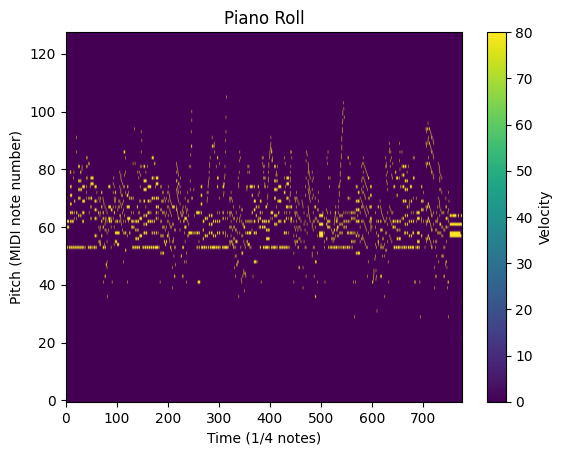

In [6]:
# example usage
roll = midi_to_pianoroll('jazz_data/raw/afine-1.mid')

import matplotlib.pyplot as plt

def plot_pianoroll(roll):
    """Plot a piano roll."""
    plt.imshow(roll, aspect='auto', origin='lower')
    plt.xlabel('Time (1/4 notes)')
    plt.ylabel('Pitch (MIDI note number)')
    plt.colorbar(label='Velocity')
    plt.title('Piano Roll')
    plt.show()

print("Piano roll shape:", roll.shape) # should be (128, T) where T is the number of time steps
plot_pianoroll(roll)

##### Question 2 [8 points]
Using `midi_to_pianoroll`, write the function `preprocess_dataset` that iterates over all MIDI files in `raw_dir` and stores piano roll `.npy` arrays in `out_dir`. 

**Naming Convention:** If there is a MIDI file called `test.mid` in `raw_dir`, the output file should be `test.npy` in `out_dir`.

In [7]:
def preprocess_dataset(raw_dir, out_dir):
    """Convert all MIDI files in raw_dir to piano rolls.

    Args:
        raw_dir (str): Directory containing MIDI files.
        out_dir (str): Directory to save numpy arrays.
    Returns:
        None
    """
    os.makedirs(out_dir, exist_ok=True)
    # Loop over MIDI files and save a piano roll .npy for each one.
    for fname in tqdm(sorted(os.listdir(raw_dir)), desc="Preprocessing"):
        if not fname.lower().endswith('.mid'):
            continue
        in_path = os.path.join(raw_dir, fname)
        base = os.path.splitext(fname)[0]
        out_path = os.path.join(out_dir, base + '.npy')
        try:
            roll = midi_to_pianoroll(in_path)
        except Exception as e:
            # Some MIDI files may be malformed; skip them instead of failing.
            print(f"Skipping {fname}: {e}")
            continue
        np.save(out_path, roll)


In [8]:
preprocess_dataset('jazz_data/raw','jazz_data/processed')

Preprocessing:  45%|████▌     | 153/337 [00:19<00:18,  9.99it/s]

Skipping My%20Old%20FlameGM.mid: 


Preprocessing: 100%|██████████| 337/337 [00:45<00:00,  7.34it/s]


##### Question 3 [8 points]

Now that we have our piano rolls ready, we will tokenize them and build a vocabulary.

A **vocabulary** is a dictionary that maps **each unique column** (consisting of all 128 pitches at a given time step) to an **integer** token. 

Each column is thus a tuple of 128 integers, where each integer represents the velocity of a pitch at that time step. For example, one such column could be as follows:

```python
(40, 0, 0, ..., 0)
```

Since the element at index 0 is 40, this means that the note with MIDI note number 0 has a velocity of 40 at that time step, while all other notes have a velocity of 0. 

So, your task is to:

* Iterate over all `.npy` files obtained above.
* Count the occurrences of each unique column (tuple of 128 integers).
* Assign a unique integer token to each unique column in the following way: the column with the highest count gets token 2, the second highest gets token 3, the third highest gets token 4, and so on.
* Token 0 is reserved for `<unk>` (unknown) columns. This is a special token for columns that do not match any of the known columns in the dataset.
* Token 1 is reserved for `<pad>` (padding) columns. This is a special token for padding columns that are used to ensure that all sequences in a batch have the same length (we will use this later in training).

In the end, the resulting dictionary might look something like this:

```python
vocab = {
    (40,0,0,...,0): m,
    ...,
    (0,0,0,...,0): n,
    '<unk>': 0,
    '<pad>': 1
}
```

where `m` and `n` are the tokens assigned to the respective columns and `m, n` are integers that are greater than or equal to 2.

Save this dictionary with the `pickle.dump` method and return it.

In [9]:
import pickle

def build_vocab(data_dir, out_file="vocab.pkl"):
    """Create a vocabulary dictionary from piano rolls.

    Args:
        data_dir (str): Directory with piano roll `.npy` files.
        out_file (str): Path to save the pickled vocabulary.
    Returns:
        dict: Mapping from column tuples to integer tokens.
    """
    # Count how often each unique column (tuple of 128 velocities) appears.
    counter = Counter()
    for fname in sorted(os.listdir(data_dir)):
        if not fname.endswith('.npy'):
            continue
        roll = np.load(os.path.join(data_dir, fname))
        for t in range(roll.shape[1]):
            col = tuple(int(v) for v in roll[:, t])
            counter[col] += 1

    # Tokens 0 and 1 are reserved for the special <unk> and <pad> columns.
    vocab = {'<unk>': 0, '<pad>': 1}
    # Assign tokens in order of decreasing frequency: highest count -> 2, next -> 3, ...
    for i, (col, _count) in enumerate(counter.most_common()):
        vocab[col] = i + 2

    # Save the vocabulary and return it.
    with open(out_file, 'wb') as f:
        pickle.dump(vocab, f)
    return vocab


In [10]:
vocab = build_vocab('jazz_data/processed')

##### Question 4 [4 points]

Fill in `tokenize_file` which converts a single piano roll `.npy` file to a sequence of integer tokens using a given vocabulary dictionary. This will involve iterating over each column in the piano roll, converting it to a tuple, and looking up the corresponding token in the vocabulary. Furthermore, if a column is not found in the vocabulary, it should be replaced with the `<unk>` token (0). This is important for generalizing the model to unseen data that may contain columns not present in the training set.

In [11]:
def tokenize_file(fname, vocab):
    """Convert a piano roll array to a list of token ids.

    Args:
        fname (str): Path to `.npy` array.
        vocab (dict): Mapping from column tuples to ints.
    Returns:
        np.ndarray: Sequence of integers (1D array).
    """
    roll = np.load(fname)
    # Map each column to its token; columns not in the vocab become <unk> (0).
    tokens = [
        vocab.get(tuple(int(v) for v in roll[:, t]), 0)
        for t in range(roll.shape[1])
    ]
    return np.array(tokens, dtype=np.int64)


In [12]:
tokens = tokenize_file('jazz_data/processed/afine-1.npy', vocab)
print(f"Tokenized sequence length: {len(tokens)}")
print(f"First 10 tokens: {tokens[:10]}")

Tokenized sequence length: 778
First 10 tokens: [ 1807  3458   305   305   140   140    20    20 92879 92880]


##### Question 5 [4 points]
Write `tokenize_dataset` to convert every piano roll array in `src_dir` into a sequence of integers.
Use the vocabulary built earlier. Columns not found in the vocabulary should map to the `<unk>` token (0). Save each token sequence as a `.npy` file in `out_dir`.

**Naming Convention**: When saving the tokenized files, use the same base filename as the original `.npy` file, but with a `.npy` extension. For example, if the original file in `src_dir` is `afine-1.npy`, the tokenized file written to `out_dir` should be `afine-1.npy`.


**Length Convention**: Do not pad or truncate token sequences in `tokenize_dataset`; preserve each file's original length. Padding is handled later by `TokenDataset`.

In [13]:
def tokenize_dataset(src_dir, vocab_file, out_dir):
    """Tokenize all piano rolls in a directory.

    Args:
        src_dir (str): Directory with piano roll arrays.
        vocab_file (str): Path to saved vocabulary.
        out_dir (str): Where to save token arrays.
    """
    os.makedirs(out_dir, exist_ok=True)
    # Load the vocabulary built earlier.
    with open(vocab_file, 'rb') as f:
        vocab = pickle.load(f)
    # Tokenize each piano roll and save it with the same filename.
    for fname in sorted(os.listdir(src_dir)):
        if not fname.endswith('.npy'):
            continue
        tokens = tokenize_file(os.path.join(src_dir, fname), vocab)
        np.save(os.path.join(out_dir, fname), tokens)


In [14]:
tokenize_dataset('jazz_data/processed', 'vocab.pkl', 'jazz_data/tokens')

##### Question 6 [6 points]

Now you will implement a simple Layer Normalization module, which is an essential building block in transformer models.  
Write this **from scratch** using PyTorch tensor operations.

Do **not** use `torch.nn.LayerNorm`. The point is for you to understand each part of the computation.

Layer Normalization adjusts each feature vector so that its elements have mean zero and variance one, then applies a learned scale and shift. This helps stabilize training and gives the model flexibility to adapt the normalized outputs.

Suppose your input `x` has shape `(B, T, C)`:
- `B` is the batch size.
- `T` is the sequence length.
- `C` is the number of features.

For each feature vector of length `C`:
1. Compute the mean $\mu$ along the feature dimension. This produces a tensor of shape `(B, T, 1)`.
2. Compute the variance $\sigma^2$ along the feature dimension. This also has shape `(B, T, 1)`.
3. Normalize by subtracting the mean and dividing by the standard deviation, adding a small $\epsilon$ to avoid division by zero.
4. Apply a learned scale and shift:
   - `weight` ($\gamma$): shape `(C,)`, initialized to ones.
   - `bias` ($\beta$): shape `(C,)`, initialized to zeros.

The formula is:

$$
\text{LN}(x)_i = \gamma_i \times \Bigg( \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} \Bigg) + \beta_i.
$$

This means:
- For each `(B, T)` position, the mean and variance are scalar values, not full matrices. 
- The subtraction and division happen element-wise along the feature dimension.
- The learned scale and shift also apply element-wise to each feature.

So you are not dividing or multiplying full tensors of the same shape. You normalize each feature vector using its own scalar statistics, then scale and shift each feature independently.

Use `unbiased=False` when computing the variance.  
Your final output should have the same shape `(B, T, C)` as the input.


In [15]:
import torch
from torch import nn

class LayerNorm(nn.Module):
    """Layer normalization over the last dimension.

    Args:
        dim (int): Feature dimension.
        eps (float): Stability epsilon.
    """
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        # Learnable scale (gamma) and shift (beta), one per feature.
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias = nn.Parameter(torch.zeros(dim))
    def forward(self, x):
        # x has shape (B, T, C); normalize each length-C feature vector.
        mean = x.mean(dim=-1, keepdim=True)              # (B, T, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # (B, T, 1)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        # Apply the learned scale and shift element-wise along the feature dim.
        return self.weight * x_norm + self.bias


##### Question 7 [8 points] 

In this part, you will write the multi-head self-attention computation from scratch using PyTorch tensor operations. Do **not** use any built-in multi-head attention layers.

Let the input be a batch of sequences $ X \in \mathbb{R}^{B \times T \times d} $, where $ B $ is the batch size, $ T $ is the sequence length, and $ d $ is the embedding dimension. In multi-head attention, we first project the input linearly to obtain the queries $ Q $, keys $ K $, and values $ V $. These are computed by applying a shared linear transformation:
$$
[Q, K, V] = X W, \quad \text{where } W = [W_q, W_k, W_v] \in \mathbb{R}^{d \times 3d}
$$
Each of the resulting tensors $ Q, K, V \in \mathbb{R}^{B \times T \times d} $ is then split into $ h $ separate heads. Each head operates on a reduced dimension $ d_h = d / h $, reshaping the tensors into
$$
Q, K, V \in \mathbb{R}^{B \times h \times T \times d_h}.
$$

Within each head, the attention scores are computed by scaled dot-product:
$$
A = \frac{Q K^\top}{\sqrt{d_h}} \in \mathbb{R}^{B \times h \times T \times T}.
$$
Then, we apply a lower-triangular mask $ M \in \mathbb{R}^{T \times T} $, where
$$
M_{ij} =
\begin{cases}
0 & \text{if } j \le i, \\
-\infty & \text{if } j > i.
\end{cases}
$$
This mask is added to the attention scores:
$$
A' = A + M,
$$
so that positions can only attend to themselves and prior tokens in the sequence.

We apply the softmax function over the last dimension of $ A' $ to obtain normalized attention weights:
$$
\alpha = \text{softmax}(A') \in \mathbb{R}^{B \times h \times T \times T}.
$$
These weights are used to form a weighted sum of the values:
$$
Z = \alpha V \in \mathbb{R}^{B \times h \times T \times d_h}.
$$

Finally, the outputs from all heads are concatenated and projected back to the original dimension $ d $ using a linear transformation:
$$
\text{Output} = \text{ConcatHeads}(Z)\, W_o + b, \quad W_o \in \mathbb{R}^{d \times d}.
$$

This completes the masked multi-head attention computation. Your implementation should follow this structure exactly: compute $ Q, K, V $, reshape for multiple heads, apply scaled dot-product attention with a causal mask, compute the weighted sum, concatenate the heads, and project back to the original feature dimension.

In [16]:
class SelfAttention(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.heads = heads
        self.scale = (dim // heads) ** -0.5
        # Shared projection producing queries, keys and values at once: W = [Wq, Wk, Wv].
        self.qkv = nn.Linear(dim, dim * 3)
        # Output projection Wo applied after concatenating the heads.
        self.proj = nn.Linear(dim, dim)
    def forward(self, x):
        B, T, C = x.shape # B: batch size, T: sequence length, C: feature dimension
        dh = C // self.heads  # per-head dimension d_h

        # Project and split into query, key, value tensors, each (B, T, C).
        q, k, v = self.qkv(x).chunk(3, dim=-1)

        # Reshape each into (B, heads, T, d_h) so attention runs per head.
        q = q.view(B, T, self.heads, dh).transpose(1, 2)
        k = k.view(B, T, self.heads, dh).transpose(1, 2)
        v = v.view(B, T, self.heads, dh).transpose(1, 2)

        # Scaled dot-product attention scores: (B, heads, T, T).
        att = (q @ k.transpose(-2, -1)) * self.scale

        # Causal mask: position i may only attend to positions j <= i.
        mask = torch.triu(
            torch.ones(T, T, dtype=torch.bool, device=x.device), diagonal=1
        )
        att = att.masked_fill(mask, float('-inf'))

        # Normalize over the key dimension and take the weighted sum of values.
        att = att.softmax(dim=-1)
        z = att @ v  # (B, heads, T, d_h)

        # Concatenate the heads back to (B, T, C) and project.
        z = z.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(z)


##### Question 8 [6 points]
Complete the `TransformerBlock` module using LayerNorm, SelfAttention and a feed-forward network. The FeedForward network is already given to you below, and is a basic two-layer MLP with GELU (Gaussian Error Linear Unit) activation.

To understand the connections between these components, read the paper [Improving Language Understanding by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf) from OpenAI.

The input `x` and output of the block have shape `(B, T, C)`. Remember to create two LayerNorm layers, a SelfAttention module, a FeedForward network and dropout layers, then apply them with residual connections.

In [17]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, dim)
        )
    def forward(self, x):
        return self.net(x)

class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, hidden, dropout=0.1):
        super().__init__()
        # Pre-normalization transformer block: LN -> attention, LN -> feed-forward.
        self.ln1 = LayerNorm(dim)
        self.attn = SelfAttention(dim, heads)
        self.ln2 = LayerNorm(dim)
        self.ff = FeedForward(dim, hidden)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
    def forward(self, x):
        # Residual connection around masked self-attention.
        x = x + self.drop1(self.attn(self.ln1(x)))
        # Residual connection around the feed-forward network.
        x = x + self.drop2(self.ff(self.ln2(x)))
        return x


##### Question 9 [10 points]

Finish implementing the `GPT` model class so that it correctly follows the transformer architecture for autoregressive language modeling.

The input is a tensor of token indices $x \in \mathbb{N}^{B \times T}$, where $B$ is the batch size and $T$ is the sequence length. The model first embeds tokens and positions. The token embedding is a learned matrix $E \in \mathbb{R}^{V \times d}$, where $V$ is the vocabulary size and $d$ is the embedding dimension. The lookup $E[x]$ produces a tensor in $\mathbb{R}^{B \times T \times d}$. 

A positional embedding $P \in \mathbb{R}^{1 \times L \times d}$ provides position-dependent information, where $L$ is the maximum sequence length. For a given input length $T$, the slice $P[:, :T]$ has shape $(1, T, d)$ and broadcasts over the batch. The input to the transformer blocks is the sum of token and positional embeddings:
$$
X = E[x] + P[:, :T].
$$

**Important Note**: If you read the original [Attention Is All You Need](https://arxiv.org/pdf/1706.03762) paper, you might notice that the authors use something called "positional encoding" instead of positional embeddings. A positional encoding is typically a fixed function (like sine and cosine functions) that generates position-dependent vectors. However, in this assignment, we are using learned positional embeddings, which are more flexible and can adapt to the data during training. You can initialize the positional embedding matrix $P$ randomly.

The model applies a stack of $N$ identical transformer blocks in sequence:
$$
H_0 = X,\quad H_{i} = \text{Block}_i(H_{i-1}),\quad i = 1,\dots,N.
$$
Each block preserves the shape, so $H_i \in \mathbb{R}^{B \times T \times d}$.

After the last block, the output is normalized:
$$
H = \text{LayerNorm}(H_N).
$$

Finally, the model projects this output to the vocabulary logits using a learned weight matrix $W_o \in \mathbb{R}^{d \times V}$ and bias $b \in \mathbb{R}^{V}$:
$$
\text{logits} = HW_o + b.
$$

The result $\text{logits} \in \mathbb{R}^{B \times T \times V}$ gives the unnormalized scores for each token in the vocabulary at every position in the sequence. Make sure your implementation matches this sequence: embedding lookup, positional addition, stacked blocks, layer normalization, and final linear projection.

In [18]:
class GPT(nn.Module):
    def __init__(self, vocab_size, seq_len, dim=512, depth=8, heads=8, hidden=2048, dropout=0.1):
        super().__init__()
        # Learned token embedding E: (vocab_size, dim).
        self.token_emb = nn.Embedding(vocab_size, dim)
        # Learned positional embedding P: (1, seq_len, dim), randomly initialized.
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, dim))
        self.drop = nn.Dropout(dropout)
        # Stack of identical transformer blocks.
        self.blocks = nn.ModuleList(
            [TransformerBlock(dim, heads, hidden, dropout) for _ in range(depth)]
        )
        # Final layer norm and projection to vocabulary logits.
        self.ln_f = LayerNorm(dim)
        self.head = nn.Linear(dim, vocab_size)
    def forward(self, x):
        # x: (B, T) token indices.
        B, T = x.shape
        # Token + positional embeddings: E[x] + P[:, :T]  ->  (B, T, dim).
        h = self.token_emb(x) + self.pos_emb[:, :T]
        h = self.drop(h)
        # Pass through the stacked transformer blocks (shape preserved).
        for block in self.blocks:
            h = block(h)
        # Normalize, then project to vocabulary logits (B, T, vocab_size).
        h = self.ln_f(h)
        return self.head(h)


##### Question 10 [10 points]
Complete the training loop below. For each mini-batch $(x,y)$ compute logits $L = \text{GPT}(x)$ and minimize
the cross-entropy loss
$$\mathcal{L} = -\frac{1}{N}\sum_i y_i \log \text{softmax}(L_i).$$
Save model weights to `model_epoch{epoch}.pt` after every epoch.
Token `1` is `<pad>`; target positions equal to `1` must not contribute to the loss.


**Sequence length clarification:** `seq_len` is the length of both `x` and `y`. Because `y` is shifted one token ahead of `x`, each sampled window must contain `seq_len + 1` tokens. Pad shorter files to `seq_len + 1` tokens (129 with the default `seq_len=128`) using the `<pad>` token `1`.

In [19]:
from torch.utils.data import Dataset, DataLoader

class TokenDataset(Dataset):
    def __init__(self, root, seq_len=128):
        self.files = [os.path.join(root, f) for f in os.listdir(root) if f.endswith('.npy')]
        self.seq_len = seq_len
        # Build a flat index of (file_idx, start) windows using non-overlapping
        # sliding windows across every file. The original version returned exactly
        # ONE random window per file per epoch (~357 windows total), far too little
        # data for a model this size. Enumerating every window means each epoch
        # covers the entire corpus, giving the model orders of magnitude more
        # training examples per pass while keeping each example a valid
        # (seq_len + 1)-token slice.
        self.windows = []
        for fi, path in enumerate(self.files):
            # mmap_mode='r' reads only the header, so we get the length cheaply
            # without loading the whole array into memory.
            n = len(np.load(path, mmap_mode='r'))
            if n < self.seq_len + 1:
                # Short files still contribute a single window; __getitem__ pads it.
                self.windows.append((fi, 0))
                continue
            # Stride by seq_len for non-overlapping windows. Each start yields the
            # slice [start, start + seq_len + 1], which stays within bounds.
            for start in range(0, n - self.seq_len, self.seq_len):
                self.windows.append((fi, start))

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        fi, start = self.windows[idx]
        tokens = np.load(self.files[fi])
        if len(tokens) < self.seq_len + 1:
            pad = self.seq_len + 1 - len(tokens)
            tokens = np.pad(tokens, (0, pad), constant_values=1)

        seq = tokens[start:start + self.seq_len + 1]
        # Guard the tail window in case it is short; pad with <pad> (token 1).
        if len(seq) < self.seq_len + 1:
            pad = self.seq_len + 1 - len(seq)
            seq = np.pad(seq, (0, pad), constant_values=1)

        x = torch.from_numpy(seq[:-1].astype(np.int64))
        y = torch.from_numpy(seq[1:].astype(np.int64))
        return x, y

def train(data_dir, vocab_file, seq_len=128, batch_size=16, epochs=10, lr=3e-4, device='cuda'):
    """Train the GPT model on tokenized data.

    Args:
        data_dir (str): Directory of tokenized sequences.
        vocab_file (str): Path to vocabulary pickle.
        seq_len (int): Sequence length for training.
    """
    with open(vocab_file, 'rb') as f:
        vocab = pickle.load(f)
    vocab_size = len(vocab)
    dataset = TokenDataset(data_dir, seq_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = GPT(vocab_size, seq_len).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=1)
    model.train()
    for epoch in range(epochs):
        # Iterate over mini-batches, compute the loss and update parameters.
        total_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)  # (B, T, vocab_size)
            # Flatten to (B*T, vocab_size) and (B*T,); <pad> targets (1) are ignored.
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            opt.zero_grad()
            loss.backward()
            opt.step()
            total_loss += loss.item()
        avg_loss = total_loss / max(len(loader), 1)
        print(f"Epoch {epoch + 1}/{epochs} - loss: {avg_loss:.4f}")
        # Save weights after every epoch (1-indexed, e.g. model_epoch10.pt).
        torch.save(model.state_dict(), f"model_epoch{epoch + 1}.pt")


Feel free to adjust the hyperparameters such as learning rate, batch size, and number of epochs to achieve better performance.

In [20]:
train('jazz_data/tokens','vocab.pkl')

Epoch 1/10 - loss: 9.9795
Epoch 2/10 - loss: 9.1554
Epoch 3/10 - loss: 8.4987
Epoch 4/10 - loss: 7.6690
Epoch 5/10 - loss: 6.6913
Epoch 6/10 - loss: 5.6096
Epoch 7/10 - loss: 4.4701
Epoch 8/10 - loss: 3.3709
Epoch 9/10 - loss: 2.4376
Epoch 10/10 - loss: 1.7203


##### Question 11 [8 points]
Implement the `generate` function below which autoregressively samples from the model.
Use the trained weights and convert the predicted tokens back to a piano roll.

Your code should:
1. Load the trained model checkpoint from the file path `model_path`.
2. Feed the provided `seed` tokens to the model and iteratively sample one new token at a time.
3. Append each sampled token to the context and continue for `steps` iterations.
4. Convert the resulting token sequence back to a piano roll using `tokens_to_pianoroll` and `pianoroll_to_pretty_midi`.

Note that the model outputs logits for the next token at each step, which you can sample from using `torch.multinomial`.

In [21]:
from scipy.io import wavfile

SECONDS_PER_STEP = 0.25

def tokens_to_pianoroll(tokens):
    cols = []
    for t in tokens:
        if isinstance(t, str):
            cols.append(np.zeros(128, dtype=np.int16))
        else:
            cols.append(np.array(t, dtype=np.int16))
    if not cols:
        return np.zeros((128,0), dtype=np.int16)
    return np.stack(cols, axis=1)

def pianoroll_to_pretty_midi(roll):
    pm = pretty_midi.PrettyMIDI(initial_tempo=120)
    instrument = pretty_midi.Instrument(program=0)
    num_steps = roll.shape[1]
    for pitch in range(roll.shape[0]):
        velocity_series = roll[pitch]
        prev_vel = 0
        start = 0
        for t in range(num_steps):
            vel = int(velocity_series[t])
            if vel > 0 and prev_vel == 0:
                start = t
                prev_vel = vel
            elif vel != prev_vel:
                if prev_vel > 0:
                    note = pretty_midi.Note(velocity=int(prev_vel), pitch=pitch, start=start*SECONDS_PER_STEP, end=t*SECONDS_PER_STEP)
                    instrument.notes.append(note)
                if vel > 0:
                    start = t
                prev_vel = vel
        if prev_vel > 0:
            note = pretty_midi.Note(velocity=int(prev_vel), pitch=pitch, start=start*SECONDS_PER_STEP, end=num_steps*SECONDS_PER_STEP)
            instrument.notes.append(note)
    pm.instruments.append(instrument)
    return pm

def generate(model_path, vocab_file, seed, steps=100, device='cuda'):
    """Generate a PrettyMIDI object from a trained model.

    Args:
        model_path (str): Path to `.pt` checkpoint.
        vocab_file (str): Path to vocabulary pickle.
        seed (list[int]): Starting sequence of tokens.
    """
    # Load the vocabulary and build the inverse token -> column mapping.
    with open(vocab_file, 'rb') as f:
        vocab = pickle.load(f)
    itos = {idx: col for col, idx in vocab.items()}

    # Load the checkpoint and rebuild the model with matching dimensions.
    state = torch.load(model_path, map_location=device)
    seq_len = state['pos_emb'].shape[1]
    vocab_size = state['token_emb.weight'].shape[0]
    model = GPT(vocab_size, seq_len).to(device)
    model.load_state_dict(state)
    model.eval()

    # Autoregressively sample new tokens.
    tokens = list(seed)
    with torch.no_grad():
        for _ in range(steps):
            # Feed at most the last seq_len tokens as context.
            context = tokens[-seq_len:]
            x = torch.tensor([context], dtype=torch.long, device=device)
            logits = model(x)                      # (1, len(context), vocab_size)
            next_logits = logits[0, -1]            # logits for the next token
            probs = torch.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
            tokens.append(next_token)

    # Convert tokens back to columns (special string tokens become zero columns),
    # then to a piano roll and a PrettyMIDI object.
    cols = [itos.get(t, '<unk>') for t in tokens]
    roll = tokens_to_pianoroll(cols)
    pm = pianoroll_to_pretty_midi(roll)
    return pm


In [22]:
pm = generate('model_epoch10.pt','vocab.pkl',[1],steps=50)

In [23]:
def save_audio(pm: pretty_midi.PrettyMIDI, path: str, sample_rate: int = 44100) -> None:
    """Save a :class:`pretty_midi.PrettyMIDI` object as a WAV file."""
    audio = pm.synthesize(fs=sample_rate)
    wavfile.write(path, sample_rate, audio.astype(np.float32))

pm.write('generated.mid') # Save the MIDI file
save_audio(pm, 'generated.wav') # Save the audio file

In [24]:
from IPython.display import Audio
Audio('generated.wav')  # Play the generated audio

##### Question 12 [4 points]
After you have trained your model and generated some samples, briefly describe the quality of the generated music. What worked well and what could be improved? You can change the seed tokens to generate different samples and see how the model performs with different starting points.

Overall, I think the model did a decent job for how small it is and how little training it got. The clearest evidence that it learned *something* is the training loss: it started around **9.98** in epoch 1 and dropped steadily all the way down to **1.72** by epoch 10. A loss that keeps going down like that (instead of getting stuck) means the model was genuinely picking up patterns in the jazz piano data rather than just guessing randomly.

**What worked well:** the generated clip actually produces real notes that play as audio (about 13 seconds long), and locally — meaning a few notes in a row — it tends to sound like plausible piano, because the model learned which note-combinations (columns) commonly follow each other. Since our vocabulary assigned the most frequent columns the lowest token numbers, the model got lots of practice on the "common" chords and notes, so those show up naturally.

**What could be improved:** the music tends to fall apart over longer stretches. It doesn't really have a sense of long-term structure — no clear phrasing, melody that goes somewhere, or repeating motifs like a real jazz piece would have. A big reason is that our loss of 1.72 is still pretty high (a well-trained language model is usually much lower), which tells me the model is undertrained and still fairly uncertain about its predictions. Also, because we binarized velocity to a single fixed value (80) back in Question 1, everything comes out at the same loudness, so it sounds a bit flat and mechanical rather than expressive. To improve it, I'd train for more epochs, use more data, make the model bigger, or tune the sampling (see Q15).

##### Question 13 [4 points]
Explain why masking in self-attention is necessary for autoregressive generation.

Autoregressive generation means the model produces one token at a time, and each new token is predicted using *only the tokens that came before it*. That's the whole game: given tokens 1 through `i`, predict token `i+1`.

Here's the problem masking solves. During *training*, we don't feed the sequence one token at a time — that would be painfully slow. Instead we feed the whole sequence in at once so the model can learn every position in parallel. But self-attention, by default, lets every position look at every other position, including *future* ones. So when the model is trying to predict the token at position `i`, it would be able to peek at positions `i+1`, `i+2`, and so on — which literally contain the answer it's supposed to guess. That's cheating, and it's usually called "information leakage."

If we let that happen, the model learns a useless shortcut: "to predict the next token, just copy the future token I can already see." It would get a great training loss. But at *generation* time, there is no future yet — we're building the sequence from scratch — so the model would have nothing to copy and would completely fall apart.

The causal (lower-triangular) mask fixes this. It sets the attention scores for all future positions to negative infinity *before* the softmax. Since softmax turns −∞ into a weight of essentially zero, each position ends up attending only to itself and the positions before it, never ahead. This makes training behave exactly like generation: predict each token using only the past. That consistency is what lets the model actually work when we generate.

##### Question 14 [4 points]
Why do we tokenize the piano roll instead of feeding the raw continuous values directly into the transformer?

The short version is that transformers are built to work with discrete tokens, not raw continuous numbers, so tokenizing lets us use the architecture the way it's designed.

A few concrete reasons:

1. **The input layer is an embedding lookup.** `nn.Embedding` takes an integer index and returns a learned vector for it. That only makes sense if our data is a sequence of integer IDs (tokens). You can't hand it a raw 128-dimensional column of velocities and have it do a lookup.

2. **The output is a probability distribution over a fixed vocabulary.** The final layer produces logits, we apply softmax, and we train with cross-entropy loss — this is a *classification* setup where the model picks the most likely next token out of a known list. Cross-entropy needs a discrete set of classes to choose from. If we tried to predict raw continuous values instead, we'd be doing regression, which is much harder here and doesn't naturally give us a distribution.

3. **Generation needs a distribution to sample from.** In the `generate` function we use `torch.multinomial` to randomly sample the next token according to its probability. That only works because we have a discrete set of tokens with probabilities attached. Continuous outputs would tend to produce "averaged," blurry values rather than crisp, plausible chords.

4. **Tokenizing turns a huge, messy space into manageable units.** Each column is 128 numbers, which is an enormous space. By treating each unique column as one token and counting how often it appears, we let the model learn the vocabulary of the music — the common chords and note groupings — and gracefully handle unseen columns with the `<unk>` token.

##### Question 15 [8 points]
Suggest two hyperparameters you might tune to improve generation quality and briefly justify your choices.

**1. Sampling temperature (in the `generate` function).**
Temperature controls how random the sampling is when we pick the next token. You apply it by dividing the logits by a temperature value before the softmax. A low temperature (below 1) makes the distribution "sharper," so the model almost always picks its most confident tokens — the output becomes more coherent and predictable, but it can get repetitive or boring. A high temperature (above 1) flattens the distribution, making the model take more risks — the output gets more varied and creative, but too high and it turns into random noise. I'd tune this because right now we sample straight from the raw probabilities, and finding a middle value (something like 0.8–1.0) often gives the best balance between "sounds musical" and "isn't just repeating itself." It's also cheap to experiment with because it doesn't require retraining.

**2. Model capacity — specifically the number of transformer blocks (`depth`) and/or the embedding dimension (`dim`).**
Our final training loss was still fairly high (1.72), which suggests the model may not be big enough to fully capture the patterns in jazz piano, or that it's undertrained. Increasing `depth` (more stacked transformer blocks) or `dim` (wider embeddings) gives the model more capacity to learn complex, longer-range musical structure, which is exactly what our generated samples were missing. The trade-off is that a bigger model needs more memory, trains more slowly, and can overfit if you don't have enough data — so I'd increase it gradually and watch whether the loss keeps improving.

*(An equally reasonable second choice would be the **learning rate**, since it directly controls how well and how fast training converges — too high and the loss bounces around, too low and it barely moves — or simply the **number of epochs**, since our loss was still dropping at epoch 10 and hadn't flattened out, meaning more training would likely have helped.)*

In [26]:
from IPython.core.display import HTML
HTML("""
<style>
@media print {
    pre, code, .output_area pre, .jp-CodeCell {
        white-space: pre-wrap !important;
        overflow-wrap: anywhere !important;
    }
}
</style>
""")
